In [1]:
import model_features as model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10
env = model.Memory(100, default_rewards, trauma=(0, 1), num_groups=5, group_features=3, max_assoc_strength=5.0)
agent = model.FeatureAgent(env)
sim = model.Simulator(agent, env)
sim.run(25, 100, time=0.1, delta=20)
for retrieval in sim.record:
    print(len(retrieval))

1
1
1
1
1
1
1
1
1
3
1
1
3
2
5
2
1
5
5
1
5
6
1
3
4


In [3]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -50
env = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
agent = model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05)
sim = model.Simulator(agent, env)
sim.run(100, 50, time=0.1, delta=20, visualize=True)

Saved 100 frame(s) to 'retrieval_frames/'


In [4]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -50
env = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
agent = model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05)
sim = model.Simulator(agent, env)
sim.run(100, 50, time=0.1, delta=20, visualize=True, output_dir="retrieval_frames_agent")

Saved 100 frame(s) to 'retrieval_frames_agent/'


rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 15 finished


rep 16 finished


rep 17 finished


rep 18 finished


rep 19 finished


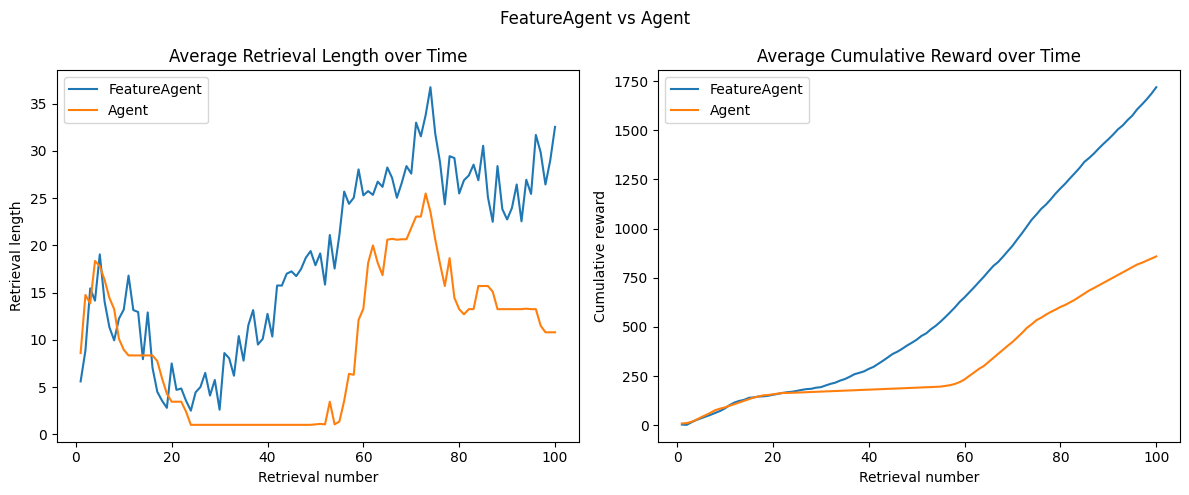

In [5]:
def collect_trajectories(agent_factory, n=100, max_steps=50, reps=20):
    length_trajectories = []
    reward_trajectories = []
    for _ in range(reps):
        environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
        agent = agent_factory(environment)
        sim = model.Simulator(agent, environment)
        sim.run(n, max_steps, time=0.1, delta=20)
        length_trajectories.append([len(trial) for trial in sim.record])
        reward_trajectories.append(sim.reward_totals)
        print(f"rep {_} finished")
    return np.array(length_trajectories), np.array(reward_trajectories)

default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -50

# v_i=0 equalizes Agent's starting value with FeatureAgent's (psi=w=0 -> value=0),
# so both start from the same neutral sigmoid(0/temp)=0.5 recall probability.
feature_lengths, feature_rewards = collect_trajectories(lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05))
agent_lengths, agent_rewards = collect_trajectories(lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05))

retrieval_num = np.arange(1, feature_lengths.shape[1] + 1)

# Cumulative reward per rep (running total across retrievals within each rep), then averaged over reps.
feature_cumulative_rewards = np.cumsum(feature_rewards, axis=1)
agent_cumulative_rewards = np.cumsum(agent_rewards, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(retrieval_num, feature_lengths.mean(axis=0), label="FeatureAgent")
axs[0].plot(retrieval_num, agent_lengths.mean(axis=0), label="Agent")
axs[0].set_xlabel("Retrieval number")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length over Time")
axs[0].legend()

axs[1].plot(retrieval_num, feature_cumulative_rewards.mean(axis=0), label="FeatureAgent")
axs[1].plot(retrieval_num, agent_cumulative_rewards.mean(axis=0), label="Agent")
axs[1].set_xlabel("Retrieval number")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Average Cumulative Reward over Time")
axs[1].legend()

fig.suptitle("FeatureAgent vs Agent")
plt.tight_layout()
plt.show()

rep 0 finished


rep 1 finished


rep 2 finished


rep 3 finished


rep 4 finished


...

rep 15 finished


rep 16 finished


rep 17 finished


rep 18 finished


rep 19 finished


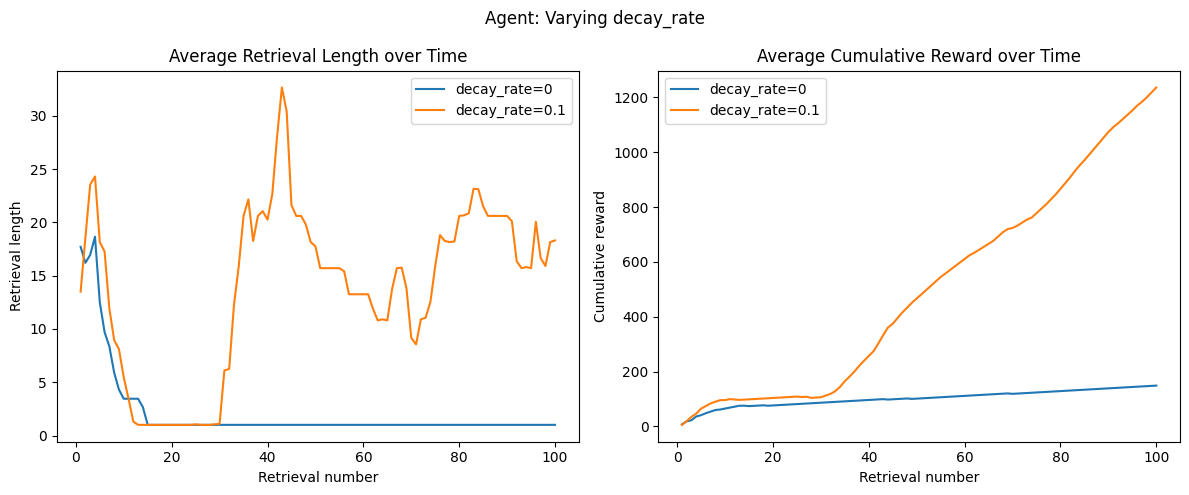

In [6]:
decay_rates = [0, 0.1]

decay_lengths = {}
decay_rewards = {}
for dr in decay_rates:
    lengths, rewards = collect_trajectories(lambda env, dr=dr: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=dr))
    decay_lengths[dr] = lengths
    decay_rewards[dr] = rewards

retrieval_num = np.arange(1, decay_lengths[decay_rates[0]].shape[1] + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for dr in decay_rates:
    axs[0].plot(retrieval_num, decay_lengths[dr].mean(axis=0), label=f"decay_rate={dr}")
axs[0].set_xlabel("Retrieval number")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length over Time")
axs[0].legend()

for dr in decay_rates:
    cumulative_reward = np.cumsum(decay_rewards[dr], axis=1)
    axs[1].plot(retrieval_num, cumulative_reward.mean(axis=0), label=f"decay_rate={dr}")
axs[1].set_xlabel("Retrieval number")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Average Cumulative Reward over Time")
axs[1].legend()

fig.suptitle("Agent: Varying decay_rate")
plt.tight_layout()
plt.show()

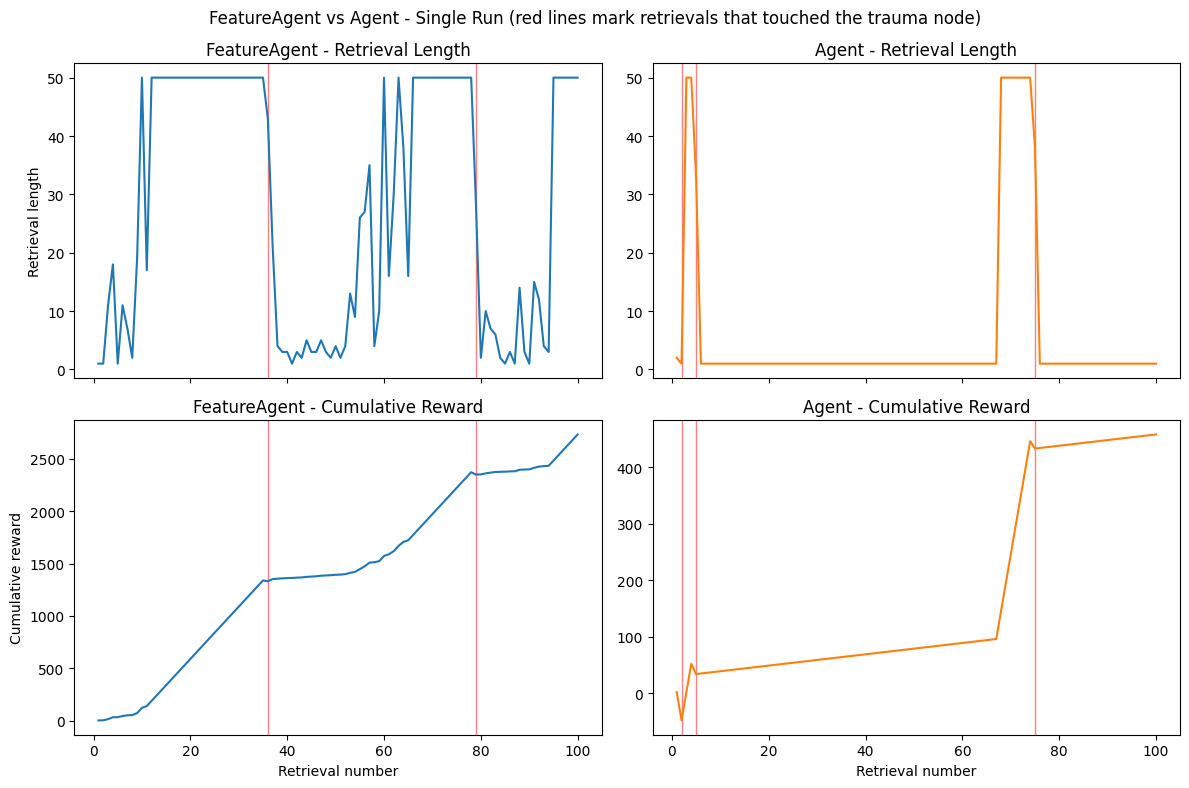

In [7]:
def single_run(agent_factory, n=100, max_steps=50):
    environment = model.Memory(100, default_rewards, num_groups=5, group_features=3, trauma=(0, 1), max_assoc_strength=5.0)
    agent = agent_factory(environment)
    sim = model.Simulator(agent, environment)
    sim.run(n, max_steps, time=0.1, delta=20)
    lengths = [len(trial) for trial in sim.record]
    return np.array(lengths), np.array(sim.reward_totals), np.array(sim.trauma_encounters)

feature_lengths_1, feature_rewards_1, feature_trauma_1 = single_run(
    lambda env: model.FeatureAgent(env, gamma=0.9, temp=0.1, decay_rate=0.05))
agent_lengths_1, agent_rewards_1, agent_trauma_1 = single_run(
    lambda env: model.Agent(gamma=0.9, temp=0.1, v_i=0, decay_rate=0.05))

retrieval_num_1 = np.arange(1, len(feature_lengths_1) + 1)
feature_cumulative_reward_1 = np.cumsum(feature_rewards_1)
agent_cumulative_reward_1 = np.cumsum(agent_rewards_1)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0][0].plot(retrieval_num_1, feature_lengths_1, color="C0")
axs[0][0].set_title("FeatureAgent - Retrieval Length")
axs[0][0].set_ylabel("Retrieval length")
axs[0][1].plot(retrieval_num_1, agent_lengths_1, color="C1")
axs[0][1].set_title("Agent - Retrieval Length")

axs[1][0].plot(retrieval_num_1, feature_cumulative_reward_1, color="C0")
axs[1][0].set_title("FeatureAgent - Cumulative Reward")
axs[1][0].set_ylabel("Cumulative reward")
axs[1][0].set_xlabel("Retrieval number")
axs[1][1].plot(retrieval_num_1, agent_cumulative_reward_1, color="C1")
axs[1][1].set_title("Agent - Cumulative Reward")
axs[1][1].set_xlabel("Retrieval number")

for ax, hits in [(axs[0][0], feature_trauma_1), (axs[1][0], feature_trauma_1),
                  (axs[0][1], agent_trauma_1), (axs[1][1], agent_trauma_1)]:
    for x in retrieval_num_1[hits]:
        ax.axvline(x, color="red", alpha=0.5, linewidth=1, zorder=0)

fig.suptitle("FeatureAgent vs Agent - Single Run (red lines mark retrievals that touched the trauma node)")
plt.tight_layout()
plt.show()